<a href="https://colab.research.google.com/github/giannibellini63/ipynb_projects/blob/main/netconf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SOC Security Operations Centers

## SIEM  Security Information and Event Management  

Security Information and Event Management (SIEM) is a powerful technology that allows security operations teams to collect, correlate and analyze log data from a variety of systems across the entire IT infrastructure stack to identify and report security threats and suspicious activity

NON C'E' POTENZA SENZA CONTROLLO

Le Policy sono un insieme di regole (caratteristica dei sistemi operativi, soprattutto Microsoft Windows NT) che controllano l'ambiente di lavoro di utenti e computer.

Forniscono la gestione centralizzata e la configurazione di sistemi operativi, applicazioni e le impostazioni degli utenti in un ambiente (computer) locale - Local Security Polices o gestito centralmente da Active Directory (o da altri sistemi di configurazione desktop - ZENworks Desktop ad esempio) - Group Policies.

Le local o group policy controllano ciò che gli utenti possono o non possono fare su un sistema informatico. Anche se le policy sono più spesso viste in uso per gli ambienti aziendali, sono anche comuni in altri ambiti come nelle scuole, nelle imprese più piccole e altri tipi di organizzazioni. I criteri sono spesso utilizzati per limitare determinate azioni che possono rappresentare potenziali rischi di protezione, ad esempio: per bloccare l'accesso al Task Manager, limitare l'accesso a determinate cartelle, disabilitare il download di file eseguibili, disabilitare l'uso di unità esterne (penne USB, dischi ottici), controllare la gestione delle password e così via.

## Local and Group

I am sick and tired of small business IT professionals complaining that Microsoft needs to provide them tools for automating security in a workgroup -- and I am sick and tired of hearing consultants respond, "Move to a domain and use Group Policy." Both parties need to do their research. Microsoft consultants hear this: Many small businesses can not and will not spend the money to purchase a Windows server license and more hardware so they can create a domain just because you say so. They need solutions for their collection of current computers. Small business owners listen up: Native Microsoft tools already exist to automate security in a workgroup environment.

In a workgroup environment, you may use security templates, Local Group Policy, the *Security Configuration and Analysis* tool and the *secedit* command to automate security for a single computer or many computers.

If computer is a member of a domain, the Group Policy editor (gpedit.msc) allows you to control settings on many Windows computers from a central location.

For non-domain machines, you set these things via Local Security Policy, not Group Policy.

However, if you have a standalone computer, you can achieve the same result with the local security policy editor or secpol.msc.

Gpedit.msc is a name of a Windows module or a tool that is used to administer or modify group policies. The Group Policy Editor console is mostly a graphical user interface for editing registry entries. Editing registry entries manually is not very easy because they are located at many places throughout computer registry. The gpedit.msc tool makes the administration of registry easier.

Secpol.msc is Windows module that is also used for administration of system settings. Secpol.msc or Local Security Policy Editor in layman's terms is a smaller brother to the Group Policy Editor. The secpol.msc is used to administer a subgroup of what you can administer using the gpedit.msc.

This is the place in registry where you can find policy settings that would be modified using gpedit.msc or secpol.msc:

	HKEY_LOCAL_MACHINE\Software\Microsoft\Windows\CurrentVersion\Policies\System

Registry keys related to policies are spread out throughout many places in registry. This is another place where many policies can be found.

	HKEY_LOCAL_MACHINE\SOFTWARE\Microsoft\Windows NT\CurrentVersion

However, know that editing the registry incorrectly can make your system unstable or even unable to start.

## Microsoft Management Console

Microsoft Management Console (MMC) è un componente presente in tutti i sistemi operativi Microsoft della serie NT a partire da Windows 2000. Si tratta di uno strumento prettamente amministrativo con interfaccia grafica in grado di ospitare una serie di moduli detti snap-in "customizzabili" in file con estensione msc

*	gpedit.msc
*	secpol.msc
*	services.msc
*	eventvwr.msc

## Custom Security Template

### Create

To create a custom security template using the MMC snap-in:

1	To open MMC, choose Start, and then choose Run.

2	Type mmc in the Open box, and then choose OK.

3	From the File menu, choose Add/Remove Snap-in.

4	In the Add/Remove Snap-in dialog box, choose Add.

5	In the list of available snap-ins, select Security Templates, choose Add, choose Close, and then choose OK.

6	In the MMC main window, under the Console Root node, expand the Security Templates node, right-click the root templates folder, and then choose New Template.

7	Type a name and description for the template, and then choose OK.

8	Configurare opzioni volute

9	Choosing OK saves your template as an .inf file in the Windows\Security\Templates folder. (ad esempio Password.inf)

### Use

	secedit /configure /db sit.sdb /cfg custom.inf /log sit.log /silent >nul


This command imports a security template file, "custom.inf" into the workstation’s or server’s local security database. /db must be specified. When specifying the default security database (sit.sdb,) I found that providing no path worked best. The /cfg option informs Secedit that it is to import the .inf file into the specified database, appending it to any existing .inf files that have already been imported to this system. You can optionally include an /overwrite switch to overwrite all previous configurations for this machine. The /silent option supresses any pop-ups and the >nul hides the command line output stating success or failure of the action.

To force the template change to take effect right away, use the following command line:

	secedit /refreshpolicy machine_policy /enforce /quiet

To periodically reinforce your security policy, you can issue Secedit commands remotely or through a script. If you aren’t using GPOs to distribute security policy, you can use this command-line method to perform periodic updates of security policy.

By default, when a computer is restarted the settings on that computer will be refreshed. The security settings are refreshed every 90 minutes on a workstation or server and every 5 minutes on a domain controller. The settings are also refreshed every 16 hours, whether or not there have been any changes.

## Setting Policies

https://www.winhelp.us/local-security-policy-in-windows.html

#### Defining a Password Policy in Windows

**Expand Account Policies** and click Password Policy on the left side of Local Security Settings window.

	Enforce password history

	Maximum password age

Default is "42". This specifies how long a user can use the same password for his/her local Windows account.

	Minimum password age

Default is "0", meaning that local users can change their passwords whenever they like. If you set this to "1", it means that a password must be in effect for at least 1 day (24 hours) before a user can change it again.

	Minimum password length

Set to at least "8", but "12" is recommended.

	Password must meet complexity requirements

Set to "Enabled". This means that a password must include at least two opposite case letters, a number and a special character (punctuation marks, for example). This is a very important step in keeping user accounts secure in Windows.

#### Defining an Account Lockout Policy in Windows

A strong password is good, but when a malicious program (or someone behind keyboard) is trying to break your password, the attempts must be stopped quickly. By default, anyone or anything can enter any password any number of times without getting stopped by Windows. Such behavior is called brute-force attack and you can stop it by creating an Account Lockout Policy - when a user enters a wrong password several times, the account will be locked out for a specified period of time. The user then cannot log on during this time. Every attempt to login during the lockout period extends the period.

Expand Account Policies and click **Expand Account Lockout Policy** on the left side of Local Security Settings window.

	Account lockout threshold:

Specify the number of times a user can enter a wrong password before Windows locks the user account

	Account lockout duration

	Reset account lockout counter after

#### Defining an Audit Policy in Windows

Expand Local Policies on the left side and click **Audit Policy**.

	Audit account logon events.

Check both Success and Failure boxes and then click OK. This means that both successful and failed logons/sign-ins from another computer/device on the same network are recorded in Security log of Event Viewer.

Adjust other Audit Policy settings as described below. "No auditing" means clearing both Success and Failure check boxes.

	Audit account management

This stores events related to creating, changing and deleting user accounts. Tick both Success and Failure.

	Audit directory service access

Leave this at No auditing. This is related to Active Directory domain servers only.

	Audit logon events

Always turn on both Success and Failure. This records all logon attempts on your computer.

	Audit object access

In most cases, leave this at No auditing. If enabled, it records events related to users accessing folders, printers, Registry entries, etc that have non-default access rights defined.

	Audit policy change

Enable both Success and Failure. This starts storing events that deal with changing this policy and adding or removing user rights (for example, you add a Standard/Limited user to Administrators group).

	Audit privilege use

You can leave this to No auditing on most home computers. If you do need to record failed attempts to access a folder or a file, printer, etc, enable Failure only.

	Audit process tracking

This should be left at No auditing. If enabled, all program launches and exits, plus service and scheduled job creations and some technical details are recorded in Event Viewer. This would mean a lot of unneeded entries for home users.

	Audit system events

Tick both Success and Failure here. This records events related to Windows starting up or shutting down, clearing event logs, etc - helpful stuff that might be useful while troubleshooting.


## Python Win32_NTLogEvent

https://docs.microsoft.com/en-us/previous-versions/windows/desktop/eventlogprov/win32-ntlogevent

"""

class Win32_NTLogEvent
{
  uint16   Category;
  string   CategoryString;
  string   ComputerName;
  uint8    Data[];
  uint16   EventCode;
  uint32   EventIdentifier;
  uint8    EventType;
  string   InsertionStrings[];
  string   Logfile;
  string   Message;
  uint32   RecordNumber;
  string   SourceName;
  datetime TimeGenerated;
  datetime TimeWritten;
  string   Type;
  string   User;
};



"""

import wmi

boold = False

logtype = 'Security'  # | Application | Installation | System
username_idx = 5
sid_idx = 4
dominio_idx = 2


def all ():
	for i in c.Win32_NTLogEvent ():
		print (i)


if __name__ == "__main__":
	if boold:
		print ("Win32 NTLogsEvent")

	c = wmi.WMI()

	for i in c.Win32_NTLogEvent (EventCode=4624, Logfile=logtype, CategoryString="Accesso"):
		# print(i)
		timewritten = i.TimeWritten
		strings = i.InsertionStrings
		print("Event Record Number: ", i.RecordNumber, " scritta: ", timewritten)

		for x in range(len(strings)):
			if boold:
				print(strings[x])
			if x in (dominio_idx, sid_idx, username_idx):
				print(strings[x])

	if boold:
		print("Stop Win32 NTLogsEvent")





# Architettura host

In [ ]:
#!python --version

In [ ]:
import platform

In [ ]:
print(platform.node())

In [ ]:
print(platform.platform())

In [ ]:
print(platform.system())

In [ ]:
print(platform.machine())

# Variabili ambiente

In [ ]:
# importing os module
import os


Recupera l'utente connesso al computer

In [ ]:
import platform

print(platform.node())

print(platform.platform())

print(platform.system())

print(platform.machine())

951cf10dc62d
Linux-6.6.105+-x86_64-with-glibc2.35
Linux
x86_64


In [ ]:
# Using environ.get() method getting
# Current username
print(os.environ.get('USERNAME'))

# Networking
---

La suite di protocolli Internet, in informatica e in telecomunicazioni, indica una famiglia di protocolli di rete legati da dipendenze d'uso su cui si basa il funzionamento logico della rete Internet.

Il modello di architettura di rete a strati rappresenta lo standard de facto nell'ambito delle reti dati in contrapposizione allo standard de iure rappresentato invece dal modello ISO/OSI

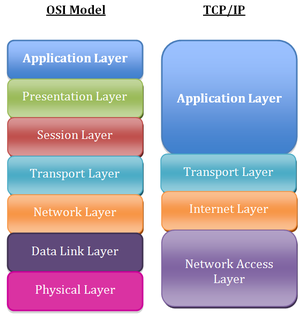



Nel collegamento virtuale tra sistemi adiacenti, nel livello Data Link, i sistemi sono individuati per mezzo di un indirizzo univoco, usualmente denominato indirizzo MAC.

L'indirizzo MAC, denominato anche MAC address o indirizzo fisico, è un codice alfanumerico di 12 caratteri (6 coppie di caratteri separate dal carattere “:” o “–”, a seconda del sistema operativo su cui viene visualizzato) che identifica “fisicamente” qualsiasi dispositivo in grado di accedere a una rete

I MAC address hanno anche la caratteristica di essere univoci: ciò significa che lo stesso indirizzo non può essere utilizzato su due dispositivi differenti. Per questo motivo, viene utilizzato quando risulta fondamentale far capo a un preciso device (e non all'IP che esso assume quando viene collegato a una Rete).

### Ottenere il MAC Address - modulo uuid (metodo 1)

In [ ]:
import uuid

In [ ]:
macAddress = hex(uuid.getnode())
print("MAC address:", macAddress)

MAC address: 0x242ac1c000c


### Ottenere il MAC Address - modulo getmac  (metodo 2)

In [ ]:
#!pip install getmac


In [ ]:
import getmac

In [ ]:
print(getmac.get_mac_address())

02:42:ac:1c:00:0c


### Ottenere l'indirizzo IP - modulo socket

In un canale di comunicazione bidirezionale, i socket sono gli endpoint (gli estremi) di questo canale di comunicazione. Questi socket (endpoint) possono comunicare all'interno di un processo, tra ***processi sulla stessa macchina*** o tra processi su macchine diverse

In [ ]:
import socket

In [ ]:
hostname = socket.gethostname()

In [ ]:
print(hostname)

In [ ]:
IPAddr = socket.gethostbyname(hostname)

In [ ]:
print(IPAddr)

### Modulo pusutil

Il modulo, cross-platform, `psutil` (process and system utilities) ricava informazioni sui processi in esecuzione e sull'utilizzazione del sistema (CPU, memory, disks, network, sensors).

il modulo implementa molte funzionalità offerte da comandi eseguiti dalla command line come `ps`, `top`, `netstat`, `ifconfig` e altri presenti nei principali sistemi operativi.

In [ ]:
import psutil

In [ ]:
#addrs = psutil.net_if_addrs()

Ritorna un dizionario con gli indirizzi associati alle schede di rete (NIC) installate sul sistema.
Il dizionario descrive il nome della scheda di rete e per ogni scheda di rete una lista di tuple con le seguenti informazioni:

* `family`: the address family, either AF_INET or AF_INET6 or psutil.AF_LINK, which refers to a MAC address.
* `address`: the primary NIC address (always set).
* `netmask`: the netmask address (may be None).
* `broadcast`: the broadcast address (may be None).
* `ptp`: stands for “point to point”; it’s the destination address on a point to point


In [ ]:
addrs = psutil.net_if_addrs()
print(addrs.keys())

Recuperare e visualizza le informazioni di una singola scheda tra quelle installate.


In [ ]:
# Esempio info NIC con nome eth0 (presente in ambiente Linux)
netinfo = addrs.get('eth0')
print(netinfo)

Visualizza in modalità user-frindly le informazioni sulla singola scheda di rete

In [ ]:
for e in netinfo:
  print(e)

I valori possibili di AddressFamily sono:

Name   ---                Purpose                 
AF_UNIX, AF_LOCAL   ---   Local communication              
AF_INET             ---   IPv4 Internet protocols        
AF_INET6            ---   IPv6 Internet protocols
AF_IPX              ---   IPX - Novell protocols

AF_NETLINK          ---   Kernel user interface device    
AF_PACKET           ---   Low level packet interface  (Linux)
AF_LINK              ---  Low level packet interface  (Windows)

Filtriamo, visualizzandole, per la singola scheda di rete, solo le informazioni che ci interessano

In [ ]:
for e in netinfo:
  family = e.family
  if str(family) == "AddressFamily.AF_PACKET" or str(family) == "AddressFamily.AF_LINK":
    print('MAC Address is:', e.address)
  if str(family) == 'AddressFamily.AF_INET':
    print('IP Address is:', e.address)